
# CAPÍTULO 5: Árboles de Decisión



Los árboles de decisión son algoritmos de aprendizaje automático (Machine Learning) muy versátiles que pueden realizar tareas tanto de clasificación como de regresión, e incluso tareas de salidas múltiples (multioutput). 

Son algoritmos potentes, capaces de ajustarse a conjuntos de datos complejos. 

Por ejemplo, en el Capítulo 2 entrenaste un modelo `DecisionTreeRegressor` con el conjunto de datos de viviendas de California, ajustándolo perfectamente (de hecho, sobreajustándolo).



Los árboles de decisión también son los componentes fundamentales de los bosques aleatorios (Random Forests, ver Capítulo 6), los cuales se encuentran entre los algoritmos de aprendizaje automático más potentes disponibles en la actualidad.



En este capítulo comenzaremos analizando cómo entrenar, visualizar y hacer predicciones con árboles de decisión. 

Luego revisaremos el algoritmo de entrenamiento CART que utiliza Scikit-Learn, y exploraremos cómo regularizar los árboles y usarlos para tareas de regresión. 

Finalmente, discutiremos algunas de las limitaciones de los árboles de decisión.



# Entrenar y Visualizar un Árbol de Decisión



Para entender los árboles de decisión, construyamos uno y veamos cómo realiza las predicciones. 

El siguiente código entrena un `DecisionTreeClassifier` en el conjunto de datos Iris (ver Capítulo 4):



In [2]:
from sklearn.datasets import load_iris
from sklearn.tree import DecisionTreeClassifier

iris = load_iris(as_frame=True)
X_iris = iris.data[["petal length (cm)", "petal width (cm)"]].values
y_iris = iris.target

tree_clf = DecisionTreeClassifier(max_depth=2, random_state=42)
tree_clf.fit(X_iris, y_iris)


,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",2
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at 


Puedes visualizar el árbol de decisión entrenado utilizando primero la función `export_graphviz()` para generar un archivo de definición de gráfico llamado `iris_tree.dot`:



In [3]:
from sklearn.tree import export_graphviz

export_graphviz(
    tree_clf,
    out_file="iris_tree.dot",
    feature_names=["petal length (cm)", "petal width (cm)"],
    class_names=iris.target_names,
    rounded=True,
    filled=True
)



Luego, puedes usar `graphviz.Source.from_file()` para cargar y mostrar el archivo en un Jupyter Notebook:




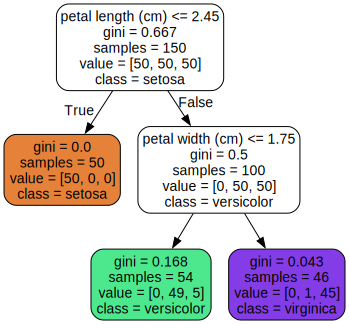

In [6]:
from graphviz import Source
Source.from_file("iris_tree.dot")




Graphviz es un paquete de software de código abierto para la visualización de gráficos. 

También incluye una herramienta de línea de comandos llamada `dot` para convertir archivos `.dot` a una variedad de formatos, como PDF o PNG.



## 2. Correcciones y Actualizaciones Técnicas

El texto es excelente, pero si intentas ejecutar ese código hoy en día, podrías toparte con un par de inconvenientes menores. 

Aquí tienes las correcciones:

* **Dependencia Externa de Graphviz:** Para que `from graphviz import Source` funcione en tu computadora, no basta con hacer `pip install graphviz`. También debes instalar el software Graphviz en tu sistema operativo (a través de `brew`, `apt-get` o el instalador de Windows) y añadirlo a las variables de entorno. Si no lo haces, el código arrojará un error.


* **La alternativa moderna (¡Mucho más fácil!):** Scikit-Learn añadió hace tiempo una función nativa llamada `plot_tree` que **no requiere instalar Graphviz**. Hace exactamente lo mismo directamente en Matplotlib.



Aquí tienes el código moderno y simplificado para visualizarlo en un segundo:



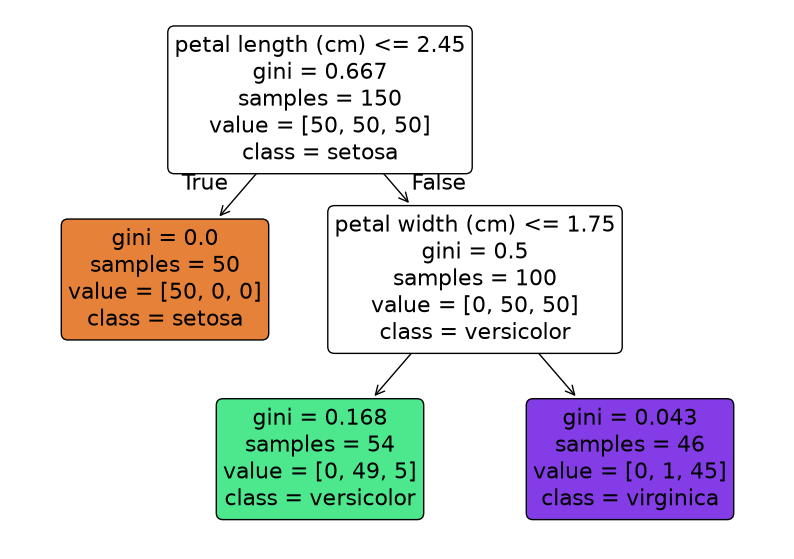

In [7]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

plt.figure(figsize=(10, 7))
plot_tree(
    tree_clf,
    feature_names=["petal length (cm)", "petal width (cm)"],
    class_names=list(iris.target_names),
    filled=True,
    rounded=True
)
plt.savefig(r"C:\Users\marco\Downloads\iris_tree.png", dpi=300)
plt.show()



# 3. Complemento: ¿Cómo entender la visualización del árbol?



Dado que el texto corta justo antes de mostrarte la "Figura 5-1", es vital que entiendas qué es lo que vas a ver cuando se genere el gráfico. 

El árbol de decisión creará nodos (cajas) conectados por flechas.



Cada caja o "nodo" de la visualización contiene la siguiente información clave:

1. **La condición (Regla de división):** En el nodo raíz (el de arriba), verás algo como `petal width (cm) <= 0.8`. Si la flor cumple esa condición, el algoritmo va hacia la izquierda (True); si no, va hacia la derecha (False).


2. **Gini (Impureza):** Mide qué tan "mezcladas" están las clases en ese nodo. Un $Gini = 0$ significa que el nodo es perfectamente "puro" (todas las flores en ese nodo pertenecen a la misma especie).


3. **Samples (Muestras):** Te dice cuántas muestras del dataset de entrenamiento cayeron en ese nodo específico.


4. **Value (Valor):** Te muestra la distribución por clase. Por ejemplo, `[50, 50, 50]` significa que hay 50 flores de la primera especie, 50 de la segunda y 50 de la tercera.


5. **Class (Clase):** Es la predicción que haría el árbol si la evaluación se detuviera en ese nodo (asigna la clase mayoritaria). El argumento `filled=True` del código sirve para que el nodo se pinte de un color más intenso cuanto más puro sea.

# Adaptación de esta parte de estudio al dataset de reducido dimensionalmente según el criterio spearman  

In [2]:
ubicacion = r"C:\Users\marco\Documentos\investigacion\1_arbol_de_decision\datos\1_meteo_epi.xlsx"

In [3]:
import pandas as pd 
from sklearn.tree import DecisionTreeClassifier

df = pd.read_excel(ubicacion)


In [4]:
df

,fecha,año,semana_epi,casos_dengue,temp,temp_max,temp_min,hum_esp,hum_rel,prec,dias_lluvia,vel_vi,vel_vi_max,vel_vi_min,uv
0,2021-01-03,2021,1,0,28.252857,34.200000,23.832857,16.308571,70.508571,5.72,1,0.121429,0.244286,0.047143,2.222857
1,2021-01-10,2021,2,0,28.687143,34.910000,24.195714,17.318571,72.885714,19.15,5,0.117143,0.208571,0.038571,2.254286
2,2021-01-17,2021,3,1,29.592857,36.372857,24.090000,16.112857,65.122857,0.77,0,0.124286,0.225714,0.045714,2.420000
3,2021-01-24,2021,4,0,29.190000,35.978571,24.200000,16.511429,68.068571,12.92,4,0.122857,0.220000,0.035714,2.477143
4,2021-01-31,2021,5,0,29.454286,35.882857,24.684286,17.427143,70.105714,17.94,3,0.120000,0.221429,0.030000,2.290000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
256,2025-11-30,2025,49,8,25.527143,28.834286,23.198571,18.515714,90.502857,27.49,6,0.158571,0.392857,0.027143,2.065714
257,2025-12-07,2025,50,9,26.082857,29.091429,23.785714,19.244286,90.718571,20.94,4,0.164286,0.411429,0.034286,2.024286
258,2025-12-14,2025,51,7,26.020000,29.442857,23.658571,18.935714,89.791429,30.61,6,0.168571,0.447143,0.034286,2.067143
259,2025-12-21,2025,52,5,25.988571,30.090000,23.008571,17.994286,85.884286,2.51,1,0.185714,0.452857,0.018571,1.995714


In [15]:
df.columns

Index(['fecha', 'año', 'semana_epi', 'casos_dengue', 'temp', 'temp_max',
       'temp_min', 'hum_esp', 'hum_rel', 'prec', 'dias_lluvia', 'vel_vi',
       'vel_vi_max', 'vel_vi_min', 'uv'],
      dtype='str')

In [17]:
import pandas as pd

# 2. Definir la lista de atributos a los que les crearemos los rezagos
columnas_a_rezagar = [
    'casos_dengue', 'temp', 'temp_max', 'temp_min', 
    'hum_esp', 'hum_rel', 'prec', 'dias_lluvia', 
    'vel_vi', 'vel_vi_max', 'vel_vi_min', 'uv'
]

# 3. Crear los rezagos de 1 a 12 semanas de forma dinámica
# Nota: Creamos una lista de nuevos fragmentos para concatenarlos eficientemente al dataframe
nuevos_rezagos = {}

for col in columnas_a_rezagar:
    for i in range(1, 13):
        nombre_columna_lag = f"{col}_lag_{i}"
        # .shift(i) desplaza los datos hacia abajo i posiciones (semanas)
        nuevos_rezagos[nombre_columna_lag] = df[col].shift(i)

# Convertir el diccionario de rezagos en un DataFrame y unirlo al original
df_rezagos = pd.DataFrame(nuevos_rezagos)
df_final = pd.concat([df, df_rezagos], axis=1)

# 4. Eliminar las primeras 12 instancias (filas) que contienen datos faltantes (NaN)
# Como desplazamos los datos hasta 12 semanas, las primeras 12 filas no tendrán historial previo.
df_final = df_final.dropna(subset=nuevos_rezagos.keys())

# Alternativa exacta por posición si prefieres asegurar que limpie las primeras 12 filas:
# df_final = df_final.iloc[12:].reset_index(drop=True)

# 5. Convertir y exportar el DataFrame resultante a un archivo .csv
nombre_salida = r"C:\Users\marco\Documentos\investigacion\1_arbol_de_decision\datos\2_meteo_epi_rezagos.csv"
df_final.to_csv(nombre_salida, index=False)

print(f"¡Proceso completado con éxito!")
print(f"Se han generado {len(nuevos_rezagos)} columnas de rezago nuevas.")
print(f"El archivo se ha guardado con el nombre: {nombre_salida}")
print(f"Dimensiones finales del dataset (filas, columnas): {df_final.shape}")

¡Proceso completado con éxito!
Se han generado 144 columnas de rezago nuevas.
El archivo se ha guardado con el nombre: C:\Users\marco\Documentos\investigacion\1_arbol_de_decision\datos\2_meteo_epi_rezagos.csv
Dimensiones finales del dataset (filas, columnas): (249, 159)


In [18]:
import pandas as pd
import numpy as np

# 1. Cargar el dataset que generaste en el paso anterior
ubicacion = r"C:\Users\marco\Documentos\investigacion\1_arbol_de_decision\datos\2_meteo_epi_rezagos.csv"
df = pd.read_csv(ubicacion)

target = "casos_dengue"

# 2. Separar y clasificar los atributos según tus reglas de negocio
# Atributos meteorológicos base (sin rezago)
meteo_base = ['temp', 'temp_max', 'temp_min', 'hum_esp', 'hum_rel', 'prec', 'dias_lluvia', 'vel_vi', 'vel_vi_max', 'vel_vi_min', 'uv']

features_validas = []

for col in df.columns:
    # Regla 1: Atributos meteorológicos sin rezago (base)
    if col in meteo_base:
        features_validas.append(col)
    
    # Regla 2: Atributos meteorológicos con rezago
    elif any(col.startswith(f"{m}_lag_") for m in meteo_base):
        features_validas.append(col)
        
    # Regla 3: Atributos epidemiológicos SOLO rezagados (casos_dengue_lag_1 a 12)
    elif col.startswith("casos_dengue_lag_"):
        features_validas.append(col)

# Limpiar nulos antes de calcular correlaciones
df_numeric = df[features_validas + [target]].dropna()

# 3. Calcular la matriz de correlación usando SPEARMAN
corr_matrix = df_numeric.corr(method="spearman")

# --- PASO 1: Selección inicial por Relevancia con el Objetivo ---
target_corr = corr_matrix[target].abs().drop(target)

# Para asegurar que no eliminemos demasiadas variables antes del filtro de redundancia,
# ordenamos por la mejor correlación con el dengue
features_ordenadas = target_corr.sort_values(ascending=False).index.tolist()

print("--- PASO 1: FILTRADO POR REDUNDANCIA INTERNA UTILIZANDO PERCENTILES ---")

# --- PASO 2: Eliminación iterativa de Redundancia ---
# Vamos a ir evaluando las variables de peor a mejor correlación con el dengue.
# Si están muy correlacionadas entre sí (superan un percentil dinámico), eliminamos la peor.

while True:
    # Matriz de intercorrelación de las variables que quedan activas
    sub_corr_matrix = df_numeric[features_ordenadas].corr(method="spearman").abs()
    
    # Extraer los valores de la diagonal superior para calcular el percentil real actual
    upper_tri = sub_corr_matrix.where(np.triu(np.ones(sub_corr_matrix.shape), k=1).astype(bool))
    all_corrs = upper_tri.stack().values
    
    # Si ya llegamos a las 20 dimensiones requeridas, detenemos el proceso
    if len(features_ordenadas) <= 20:
        break
        
    # Definir el umbral dinámico basado en el percentil 25 de las intercorrelaciones actuales.
    # Como las correlaciones son bajas, usamos np.nanpercentile para ignorar posibles NaNs.
    threshold_redundancy = np.nanpercentile(all_corrs, 25)
    
    eliminada = False
    # Evaluamos parejas de variables empezando por las que tienen menor correlación con el dengue
    for i in reversed(range(len(features_ordenadas))):
        col_evaluar = features_ordenadas[i]
        
        # Buscar si esta variable se correlaciona con alguna otra por encima del umbral permitido
        correlaciones_col = sub_corr_matrix[col_evaluar]
        redundantes = correlaciones_col[correlaciones_col > threshold_redundancy].index.tolist()
        redundantes.remove(col_evaluar) # Quitarse a sí misma
        
        if redundantes:
            # Como features_ordenadas va de mejor a peor correlación con el dengue,
            # col_evaluar es automáticamente la que PEOR correlación tiene frente a sus redundantes.
            print(f"Eliminando '{col_evaluar}' (Corr Dengue: {target_corr[col_evaluar]:.4f}) por alta redundancia interna con {redundantes[:2]}...")
            features_ordenadas.remove(col_evaluar)
            eliminada = True
            break # Recalcular la matriz con la variable fuera
            
    # Si en una vuelta completa no se eliminó ninguna por redundancia pero aún superamos las 20 dimensiones,
    # removemos directamente la de menor correlación con el dengue para forzar el límite de dimensiones.
    if not eliminada:
        peor_col = features_ordenadas.pop()
        print(f"Forzando eliminación de la menos correlacionada: '{peor_col}'")

final_features = features_ordenadas

print(f"\n--- RESULTADO FINAL DE REDUCCIÓN ---")
print(f"Cantidad de atributos finales obtenidos: {len(final_features)}")
print(f"Atributos óptimos finales seleccionados:\n{final_features}")

# 4. Crear el nuevo dataset con las 20 dimensiones + variables de control esenciales
columnas_control = [col for col in ["fecha", "año", "semana_epi"] if col in df.columns]
df_reducido = df[columnas_control + [target] + final_features]

# Exportar a un archivo nuevo
ruta_salida = r"C:\Users\marco\Documentos\investigacion\1_arbol_de_decision\datos\3_meteo_epi_rezago_reducido_20d.csv"
df_reducido.to_csv(ruta_salida, index=False)
print(f"\nDataset guardado con éxito como '{ruta_salida}' con dimensiones {df_reducido.shape}")

--- PASO 1: FILTRADO POR REDUNDANCIA INTERNA UTILIZANDO PERCENTILES ---
Eliminando 'temp_min_lag_6' (Corr Dengue: 0.0050) por alta redundancia interna con ['hum_rel_lag_7', 'hum_rel_lag_8']...
Eliminando 'temp_min_lag_8' (Corr Dengue: 0.0089) por alta redundancia interna con ['hum_esp_lag_1', 'hum_rel_lag_7']...
Eliminando 'temp_min_lag_9' (Corr Dengue: 0.0178) por alta redundancia interna con ['hum_rel_lag_8', 'hum_rel_lag_9']...
Eliminando 'temp_min_lag_10' (Corr Dengue: 0.0210) por alta redundancia interna con ['hum_esp_lag_3', 'hum_rel_lag_9']...
Eliminando 'temp_min_lag_7' (Corr Dengue: 0.0268) por alta redundancia interna con ['hum_rel_lag_7', 'hum_rel_lag_8']...
Eliminando 'temp_min' (Corr Dengue: 0.0319) por alta redundancia interna con ['hum_rel_lag_7', 'hum_rel_lag_8']...
Eliminando 'temp_min_lag_3' (Corr Dengue: 0.0369) por alta redundancia interna con ['hum_rel_lag_7', 'hum_rel_lag_8']...
Eliminando 'temp_min_lag_11' (Corr Dengue: 0.0378) por alta redundancia interna con ['

In [26]:
import pandas as pd
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split

# 1. Cargar el dataset con las 20 dimensiones óptimas obtenido en el paso anterior
# (Asegúrate de cambiar a pd.read_csv si internamente sigue siendo un CSV, como vimos antes)
ruta_reducida = r"C:\Users\marco\Documentos\investigacion\1_arbol_de_decision\datos\3_meteo_epi_rezago_reducido_20d.csv"
df_reducido = pd.read_csv(ruta_reducida)

# 2. Definir la variable objetivo (y) y las variables predictoras (X)
target = "casos_dengue"

# Excluimos las columnas de control de tiempo para que el árbol solo aprenda de patrones climáticos/epidemiológicos
columnas_control = [col for col in ["fecha", "año", "semana_epi"] if col in df_reducido.columns]

X = df_reducido.drop(columns=columnas_control + [target])
y = df_reducido[target]

# --- NOTA IMPORTANTE PARA DATOS TEMPORALES ---
# Como estás trabajando con rezagos (lags) y series de tiempo (ARIMA/Dengue), NO debes usar 
# train_test_split(..., shuffle=True) de forma aleatoria, ya que romperías la cronología.
# Hacemos una separación secuencial (ej. 80% entrenamiento, 20% validación):

split_index = int(len(df_reducido) * 0.80)

X_train, X_test = X.iloc[:split_index], X.iloc[split_index:]
y_train, y_test = y.iloc[:split_index], y.iloc[split_index:]

# 3. Inicializar y entrenar el Árbol de Decisión
# Ajustamos a max_depth=2 como especificaste en tu ejemplo básico
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import r2_score, mean_absolute_error

# 1. Cambiar a Regresor (Para números continuos)
tree_reg = DecisionTreeRegressor(max_depth=4, min_samples_leaf=5, random_state=42)
tree_reg.fit(X_train, y_train)

# 2. Hacer predicciones
y_pred_train = tree_reg.predict(X_train)
y_pred_test = tree_reg.predict(X_test)

# 3. Evaluar con métricas correctas de regresión
print("--- NUEVAS MÉTRICAS DE REGRESIÓN ---")
print(f"R2 en Entrenamiento: {r2_score(y_train, y_pred_train):.4f}")
print(f"R2 en Prueba: {r2_score(y_test, y_pred_test):.4f}")
print(f"Error Promedio (MAE) en Prueba: {mean_absolute_error(y_test, y_pred_test):.2f} casos")

--- NUEVAS MÉTRICAS DE REGRESIÓN ---
R2 en Entrenamiento: 0.9122
R2 en Prueba: 0.6172
Error Promedio (MAE) en Prueba: 12.47 casos


In [27]:
df['casos_dengue'].mean()

np.float64(24.550200803212853)

In [28]:
import pandas as pd
import numpy as np
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit
from sklearn.metrics import r2_score, mean_absolute_error

# 1. Cargar el dataset reducido
ruta_reducida = r"C:\Users\marco\Documentos\investigacion\1_arbol_de_decision\datos\3_meteo_epi_rezago_reducido_20d.csv"
df_reducido = pd.read_csv(ruta_reducida)

target = "casos_dengue"
columnas_control = [col for col in ["fecha", "año", "semana_epi"] if col in df_reducido.columns]

X = df_reducido.drop(columns=columnas_control + [target])
y = df_reducido[target]

# 2. División cronológica (80% entrenamiento, 20% prueba)
split_index = int(len(df_reducido) * 0.80)
X_train, X_test = X.iloc[:split_index], X.iloc[split_index:]
y_train, y_test = y.iloc[:split_index], y.iloc[split_index:]

# 3. Definir la grilla de hiperparámetros
# Nos enfocamos en regularizar el árbol para combatir el overfitting
param_grid = {
    'criterion': ['squared_error', 'absolute_error'], # Evalúa penalizar errores grandes vs medianos
    'max_depth': [2, 3, 4, 5, 6],                     # Controla la altura/complejidad del árbol
    'min_samples_split': [5, 10, 15, 20],             # Mínimo de muestras para abrir un nuevo nodo
    'min_samples_leaf': [2, 4, 6, 8, 12],              # Mínimo de muestras que deben quedar en una hoja
    'max_features': ['sqrt', 'log2', None]            # Cantidad de variables a evaluar en cada división
}

# 4. Configurar la validación cruzada para Series Temporales
# Esto divide el X_train en ventanas de tiempo sucesivas (sin mezclar aleatoriamente)
tscv = TimeSeriesSplit(n_splits=5)

# 5. Inicializar el modelo base y la búsqueda en grilla
base_tree = DecisionTreeRegressor(random_state=42)

grid_search = GridSearchCV(
    estimator=base_tree,
    param_grid=param_grid,
    cv=tscv,
    scoring='neg_mean_absolute_error', # Optimizamos para reducir el MAE (error de casos)
    n_jobs=-1,                         # Usa todos los núcleos disponibles del procesador
    verbose=1
)

# Executar la búsqueda de parámetros en el set de entrenamiento
print("Iniciando búsqueda de hiperparámetros...")
grid_search.fit(X_train, y_train)

# 6. Extraer el mejor modelo
best_tree = grid_search.best_estimator_

print("\n--- MEJORES HIPERPARÁMETROS ENCONTRADOS ---")
print(grid_search.best_params_)

# 7. Evaluar el modelo optimizado
y_pred_train_opt = best_tree.predict(X_train)
y_pred_test_opt = best_tree.predict(X_test)

promedio_casos = y_test.mean()

print("\n--- NUEVAS MÉTRICAS OPTIMIZADAS ---")
print(f"R2 en Entrenamiento: {r2_score(y_train, y_pred_train_opt):.4f}")
print(f"R2 en Prueba: {r2_score(y_test, y_pred_test_opt):.4f}")
print(f"Error Promedio (MAE) en Prueba: {mean_absolute_error(y_test, y_pred_test_opt):.2f} casos")
print(f"Promedio real de casos en Prueba: {promedio_casos:.2f} casos")

# Comparación de importancia de variables del mejor árbol
importancias = pd.DataFrame({
    'Atributo': X.columns,
    'Importancia': best_tree.feature_importances_
}).sort_values(by='Importancia', ascending=False)

print("\n--- TOP 5 ATRIBUTOS MÁS IMPORTANTES PARA EL NUEVO ÁRBOL ---")
print(importancias.head(5).to_string(index=False))

Iniciando búsqueda de hiperparámetros...
Fitting 5 folds for each of 600 candidates, totalling 3000 fits

--- MEJORES HIPERPARÁMETROS ENCONTRADOS ---
{'criterion': 'squared_error', 'max_depth': 6, 'max_features': 'sqrt', 'min_samples_leaf': 4, 'min_samples_split': 5}

--- NUEVAS MÉTRICAS OPTIMIZADAS ---
R2 en Entrenamiento: 0.8940
R2 en Prueba: 0.5999
Error Promedio (MAE) en Prueba: 12.30 casos
Promedio real de casos en Prueba: 44.76 casos

--- TOP 5 ATRIBUTOS MÁS IMPORTANTES PARA EL NUEVO ÁRBOL ---
          Atributo  Importancia
casos_dengue_lag_2     0.649407
casos_dengue_lag_6     0.097988
casos_dengue_lag_1     0.092755
casos_dengue_lag_5     0.050293
casos_dengue_lag_9     0.027649
